# 01 Environmental Data Simulator

## Objectives

- Simulate realistic forest environmental conditions
- Generate continuous streaming sensor data
- Simulate wildfire events
- Export datasets for later experiments

In [6]:
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


In [10]:
@dataclass
class SimulationConfig:
    total_samples: int = 10_000
    sampling_interval_seconds: int = 1

    # Probability of starting a wildfire at each normal reading
    wildfire_start_probability: float = 0.0015

    # Wildfire duration in samples
    minimum_fire_duration: int = 60
    maximum_fire_duration: int = 300

    # Sensor noise
    temperature_noise: float = 1.2
    humidity_noise: float = 3.0
    smoke_noise: float = 0.4
    co_noise: float = 0.3
    wind_noise: float = 1.5

    # Initial battery state
    initial_battery_voltage: float = 4.15
    minimum_battery_voltage: float = 3.0


config = SimulationConfig()

print(config)

SimulationConfig(total_samples=10000, sampling_interval_seconds=1, wildfire_start_probability=0.0015, minimum_fire_duration=60, maximum_fire_duration=300, temperature_noise=1.2, humidity_noise=3.0, smoke_noise=0.4, co_noise=0.3, wind_noise=1.5, initial_battery_voltage=4.15, minimum_battery_voltage=3.0)


In [15]:
from pathlib import Path

PROJECT_ROOT = Path("/content/wildfire-tinyml-self-sufficiency")

DATA_DIR = PROJECT_ROOT / "data" / "simulated" / "baseline"
FIGURES_DIR = PROJECT_ROOT / "figures" / "week1"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Data folder:", DATA_DIR)
print("Figures folder:", FIGURES_DIR)

Data folder: /content/wildfire-tinyml-self-sufficiency/data/simulated/baseline
Figures folder: /content/wildfire-tinyml-self-sufficiency/figures/week1


In [23]:
def generate_normal_conditions(
    timestamp: pd.Timestamp,
    battery_voltage: float,
    config: SimulationConfig
) -> dict:
    """
    Generate one realistic normal forest environmental reading.
    """

    hour = timestamp.hour + timestamp.minute / 60 + timestamp.second / 3600

    # Daytime temperature rises and nighttime temperature falls
    temperature_cycle = 23 + 7 * np.sin((hour - 6) * np.pi / 12)
    temperature = np.random.normal(
        temperature_cycle,
        config.temperature_noise
    )

    # Humidity usually decreases as temperature increases
    humidity_mean = 72 - 1.1 * (temperature - 18)
    humidity = np.random.normal(
        humidity_mean,
        config.humidity_noise
    )

    # Normal forest smoke and CO levels remain low
    smoke = np.random.lognormal(
        mean=0.15,
        sigma=config.smoke_noise
    )

    co = np.random.lognormal(
        mean=-0.1,
        sigma=config.co_noise
    )

    # Wind includes natural short-term variation
    wind_speed = max(
        0,
        np.random.normal(8, config.wind_noise)
    )

    # Solar production follows daylight
    daylight = max(
        0,
        np.sin((hour - 6) * np.pi / 12)
    )

    solar_power = max(
        0,
        daylight * np.random.normal(1.1, 0.12)
    )

    # Battery gains energy in daylight and slowly discharges otherwise
    charging_gain = 0.00008 * solar_power
    operating_cost = 0.000025

    updated_battery = battery_voltage + charging_gain - operating_cost

    updated_battery = np.clip(
        updated_battery,
        config.minimum_battery_voltage,
        4.2
    )

    return {
        "timestamp": timestamp,
        "temperature_c": float(temperature),
        "humidity_percent": float(np.clip(humidity, 10, 100)),
        "smoke_ppm": float(max(0, smoke)),
        "co_ppm": float(max(0, co)),
        "wind_speed_kmh": float(wind_speed),
        "solar_power_w": float(solar_power),
        "battery_voltage": float(updated_battery),
        "wildfire": 0,
        "fire_severity": 0.0,
        "fire_phase": "normal"
    }

In [19]:
def calculate_fire_phase(
    elapsed_samples: int,
    total_duration: int
) -> tuple[str, float]:
    """
    Return the wildfire phase and its intensity multiplier.
    """

    progress = elapsed_samples / max(total_duration - 1, 1)

    if progress < 0.15:
        phase = "ignition"
        intensity = 0.25 + progress / 0.15 * 0.25

    elif progress < 0.50:
        phase = "growth"
        intensity = 0.50 + (progress - 0.15) / 0.35 * 0.50

    elif progress < 0.80:
        phase = "peak"
        intensity = 1.0

    else:
        phase = "decay"
        intensity = 1.0 - (progress - 0.80) / 0.20 * 0.65

    return phase, float(np.clip(intensity, 0.2, 1.0))

In [20]:
def apply_wildfire_conditions(
    normal_reading: dict,
    base_severity: float,
    phase_intensity: float
) -> dict:
    """
    Modify a normal environmental reading to represent wildfire conditions.
    """

    reading = normal_reading.copy()

    effective_severity = base_severity * phase_intensity

    reading["temperature_c"] += np.random.uniform(
        15,
        42
    ) * effective_severity

    reading["humidity_percent"] -= np.random.uniform(
        18,
        50
    ) * effective_severity

    reading["smoke_ppm"] += np.random.uniform(
        45,
        300
    ) * effective_severity

    reading["co_ppm"] += np.random.uniform(
        25,
        180
    ) * effective_severity

    reading["wind_speed_kmh"] += np.random.uniform(
        1,
        14
    ) * effective_severity

    # Additional energy cost due to intensive sensing and alert processing
    reading["battery_voltage"] -= (
        0.00005 + 0.00008 * effective_severity
    )

    reading["humidity_percent"] = float(
        np.clip(reading["humidity_percent"], 0, 100)
    )

    reading["battery_voltage"] = float(
        np.clip(reading["battery_voltage"], 2.8, 4.2)
    )

    reading["wildfire"] = 1
    reading["fire_severity"] = float(effective_severity)

    return reading

In [24]:
def environmental_stream(config: SimulationConfig):
    current_timestamp = pd.Timestamp.now()
    battery_voltage = config.initial_battery_voltage
    fire_active = False
    fire_start_sample = -1
    fire_duration = 0
    base_fire_severity = 0.0

    for sample_idx in range(config.total_samples):
        # 1. Generate normal conditions
        normal_reading = generate_normal_conditions(
            current_timestamp,
            battery_voltage,
            config
        )
        battery_voltage = normal_reading["battery_voltage"]

        # 2. Check for wildfire conditions
        if not fire_active and np.random.rand() < config.wildfire_start_probability:
            fire_active = True
            fire_start_sample = sample_idx
            fire_duration = np.random.randint(
                config.minimum_fire_duration,
                config.maximum_fire_duration + 1
            )
            # Initial severity for a new fire event
            base_fire_severity = np.random.uniform(0.3, 0.9)

        if fire_active:
            elapsed_samples = sample_idx - fire_start_sample
            if elapsed_samples < fire_duration:
                fire_phase, phase_intensity = calculate_fire_phase(
                    elapsed_samples,
                    fire_duration
                )
                reading = apply_wildfire_conditions(
                    normal_reading,
                    base_fire_severity,
                    phase_intensity
                )
                reading["fire_phase"] = fire_phase
                battery_voltage = reading["battery_voltage"]
            else:
                # Fire has ended
                fire_active = False
                fire_duration = 0
                fire_start_sample = -1
                base_fire_severity = 0.0
                reading = normal_reading # Revert to normal conditions
        else:
            reading = normal_reading

        yield reading

        current_timestamp += pd.Timedelta(seconds=config.sampling_interval_seconds)

stream_records = list(environmental_stream(config))

df = pd.DataFrame(stream_records)

print("Dataset shape:", df.shape)
print()
print(df.head())

Dataset shape: (10000, 11)

                   timestamp  temperature_c  humidity_percent  smoke_ppm  \
0 2026-07-26 22:29:48.107293      17.131240         72.540843   1.505425   
1 2026-07-26 22:29:49.107293      16.869838         76.274724   0.920948   
2 2026-07-26 22:29:50.107293      14.464892         74.201757   0.774814   
3 2026-07-26 22:29:51.107293      15.779228         76.236011   3.234244   
4 2026-07-26 22:29:52.107293      15.813636         73.529919   0.913308   

     co_ppm  wind_speed_kmh  solar_power_w  battery_voltage  wildfire  \
0  1.428906        7.648770            0.0         4.149975         0   
1  0.772942        7.142930            0.0         4.149950         0   
2  0.994291        6.637964            0.0         4.149925         0   
3  1.018438        8.183329            0.0         4.149900         0   
4  1.577251        7.979754            0.0         4.149875         0   

   fire_severity fire_phase  
0            0.0     normal  
1            0.0

In [26]:
print("Wildfire label distribution:")
print(df["wildfire"].value_counts())

# Add fire_event_id column to identify unique wildfire events
# Mark the start of a wildfire event: wildfire is 1 and previous was 0
df['fire_event_start'] = (df['wildfire'] == 1) & (df['wildfire'].shift(1, fill_value=0) == 0)

# Use cumulative sum to assign a unique ID to each started wildfire event
df['fire_event_id'] = df['fire_event_start'].cumsum()

# For periods where there is no wildfire, set fire_event_id to None
df.loc[df['wildfire'] == 0, 'fire_event_id'] = None

print()
print("Number of wildfire events:")
print(df.loc[df["wildfire"] == 1, "fire_event_id"].nunique())

Wildfire label distribution:
wildfire
0    6538
1    3462
Name: count, dtype: int64

Number of wildfire events:
17


In [27]:
summary_columns = [
    "temperature_c",
    "humidity_percent",
    "smoke_ppm",
    "co_ppm",
    "wind_speed_kmh",
    "solar_power_w",
    "battery_voltage",
    "fire_severity"
]

df[summary_columns].describe().round(3)

,temperature_c,humidity_percent,smoke_ppm,co_ppm,wind_speed_kmh,solar_power_w,battery_voltage,fire_severity
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.0,10000.000,10000.000
mean,20.983,68.319,30.544,18.151,9.244,0.0,3.885,0.168
std,7.958,9.926,51.244,30.554,2.716,0.0,0.168,0.262
min,11.704,28.079,0.276,0.308,2.274,0.0,3.593,0.000
25%,15.828,63.609,1.018,0.822,7.436,0.0,3.728,0.000
50%,17.059,71.838,1.555,1.108,8.730,0.0,3.909,0.000
75%,24.791,75.033,46.843,26.735,10.424,0.0,4.017,0.338
max,54.619,85.837,265.213,160.350,22.429,0.0,4.150,0.887


In [28]:
summary_columns = [
    "temperature_c",
    "humidity_percent",
    "smoke_ppm",
    "co_ppm",
    "wind_speed_kmh",
    "solar_power_w",
    "battery_voltage",
    "fire_severity"
]

df[summary_columns].describe().round(3)

,temperature_c,humidity_percent,smoke_ppm,co_ppm,wind_speed_kmh,solar_power_w,battery_voltage,fire_severity
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.0,10000.000,10000.000
mean,20.983,68.319,30.544,18.151,9.244,0.0,3.885,0.168
std,7.958,9.926,51.244,30.554,2.716,0.0,0.168,0.262
min,11.704,28.079,0.276,0.308,2.274,0.0,3.593,0.000
25%,15.828,63.609,1.018,0.822,7.436,0.0,3.728,0.000
50%,17.059,71.838,1.555,1.108,8.730,0.0,3.909,0.000
75%,24.791,75.033,46.843,26.735,10.424,0.0,4.017,0.338
max,54.619,85.837,265.213,160.350,22.429,0.0,4.150,0.887


In [29]:
preview_stream = environmental_stream(
    SimulationConfig(
        total_samples=20,
        wildfire_start_probability=0.05
    )
)

for reading in preview_stream:
    print(
        f"Time: {reading['timestamp']} | "
        f"Temp: {reading['temperature_c']:.2f} C | "
        f"Humidity: {reading['humidity_percent']:.2f}% | "
        f"Smoke: {reading['smoke_ppm']:.2f} ppm | "
        f"Fire: {reading['wildfire']} | "
        f"Phase: {reading['fire_phase']}"
    )

Time: 2026-07-26 22:41:25.050778 | Temp: 16.30 C | Humidity: 79.84% | Smoke: 2.17 ppm | Fire: 0 | Phase: normal
Time: 2026-07-26 22:41:26.050778 | Temp: 18.03 C | Humidity: 71.75% | Smoke: 0.88 ppm | Fire: 0 | Phase: normal
Time: 2026-07-26 22:41:27.050778 | Temp: 17.79 C | Humidity: 75.82% | Smoke: 0.91 ppm | Fire: 0 | Phase: normal
Time: 2026-07-26 22:41:28.050778 | Temp: 15.35 C | Humidity: 78.11% | Smoke: 0.87 ppm | Fire: 0 | Phase: normal
Time: 2026-07-26 22:41:29.050778 | Temp: 14.91 C | Humidity: 73.85% | Smoke: 1.35 ppm | Fire: 0 | Phase: normal
Time: 2026-07-26 22:41:30.050778 | Temp: 17.79 C | Humidity: 75.92% | Smoke: 0.97 ppm | Fire: 0 | Phase: normal
Time: 2026-07-26 22:41:31.050778 | Temp: 16.44 C | Humidity: 71.86% | Smoke: 1.76 ppm | Fire: 0 | Phase: normal
Time: 2026-07-26 22:41:32.050778 | Temp: 12.92 C | Humidity: 75.05% | Smoke: 1.45 ppm | Fire: 0 | Phase: normal
Time: 2026-07-26 22:41:33.050778 | Temp: 15.36 C | Humidity: 72.03% | Smoke: 0.82 ppm | Fire: 0 | Phase:

In [31]:
df['sample_index'] = df.index
wildfire_rows = df[df["wildfire"] == 1].copy()

if wildfire_rows.empty:
    wildfire_events = pd.DataFrame(
        columns=[
            "fire_event_id",
            "start_time",
            "end_time",
            "duration_samples",
            "duration_seconds",
            "maximum_temperature_c",
            "maximum_smoke_ppm",
            "maximum_co_ppm",
            "maximum_severity"
        ]
    )

else:
    wildfire_events = (
        wildfire_rows
        .groupby("fire_event_id")
        .agg(
            start_time=("timestamp", "min"),
            end_time=("timestamp", "max"),
            duration_samples=("sample_index", "count"),
            maximum_temperature_c=("temperature_c", "max"),
            maximum_smoke_ppm=("smoke_ppm", "max"),
            maximum_co_ppm=("co_ppm", "max"),
            maximum_severity=("fire_severity", "max")
        )
        .reset_index()
    )

    wildfire_events["duration_seconds"] = (
        wildfire_events["duration_samples"]
        * config.sampling_interval_seconds
    )

wildfire_events

,fire_event_id,start_time,end_time,duration_samples,maximum_temperature_c,maximum_smoke_ppm,maximum_co_ppm,maximum_severity,duration_seconds
0,1.0,2026-07-26 22:37:43.107293,2026-07-26 22:40:44.107293,182,32.549018,105.653162,63.068333,0.349000,182
1,2.0,2026-07-26 22:51:57.107293,2026-07-26 22:56:32.107293,276,36.243832,138.628663,84.456331,0.466032,276
2,3.0,2026-07-26 22:59:36.107293,2026-07-26 23:04:14.107293,279,35.422914,128.124659,77.080127,0.427756,279
3,4.0,2026-07-26 23:06:38.107293,2026-07-26 23:10:04.107293,207,34.067991,114.634595,69.453407,0.382893,207
4,5.0,2026-07-26 23:28:02.107293,2026-07-26 23:30:11.107293,130,36.897745,146.150131,88.136146,0.487433,130
5,6.0,2026-07-26 23:37:04.107293,2026-07-26 23:41:03.107293,240,46.869054,210.994899,127.971810,0.708021,240
6,7.0,2026-07-26 23:44:12.107293,2026-07-26 23:45:33.107293,82,46.456405,206.953037,129.484426,0.745172,82
7,8.0,2026-07-26 23:51:58.107293,2026-07-26 23:54:21.107293,144,37.928769,154.182096,94.710721,0.523300,144
8,9.0,2026-07-27 00:02:15.107293,2026-07-27 00:04:56.107293,162,51.298503,248.412799,152.607895,0.849821,162
9,10.0,2026-07-27 00:05:23.107293,2026-07-27 00:09:05.107293,223,39.977364,169.172025,102.147761,0.563812,223


In [32]:
environment_path = (
    DATA_DIR / "week1_environment_stream.csv"
)

wildfire_events_path = (
    DATA_DIR / "week1_wildfire_events.csv"
)

df.to_csv(
    environment_path,
    index=False
)

wildfire_events.to_csv(
    wildfire_events_path,
    index=False
)

print("Environmental stream saved to:")
print(environment_path)

print()
print("Wildfire event summary saved to:")
print(wildfire_events_path)

Environmental stream saved to:
/content/wildfire-tinyml-self-sufficiency/data/simulated/baseline/week1_environment_stream.csv

Wildfire event summary saved to:
/content/wildfire-tinyml-self-sufficiency/data/simulated/baseline/week1_wildfire_events.csv


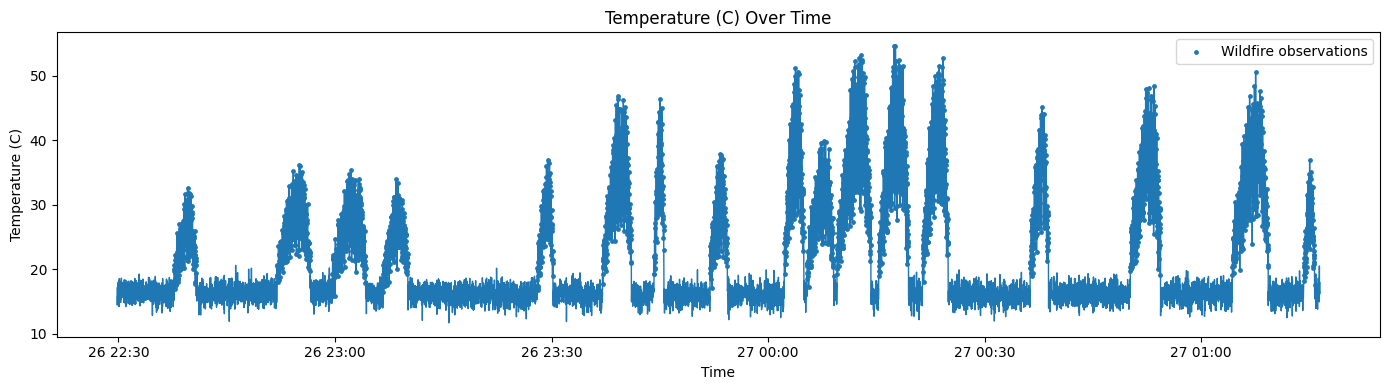

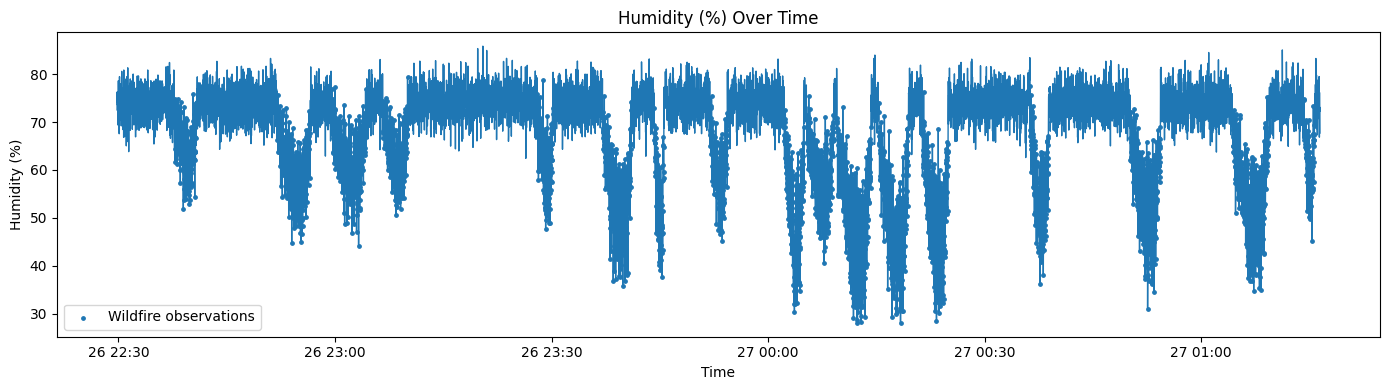

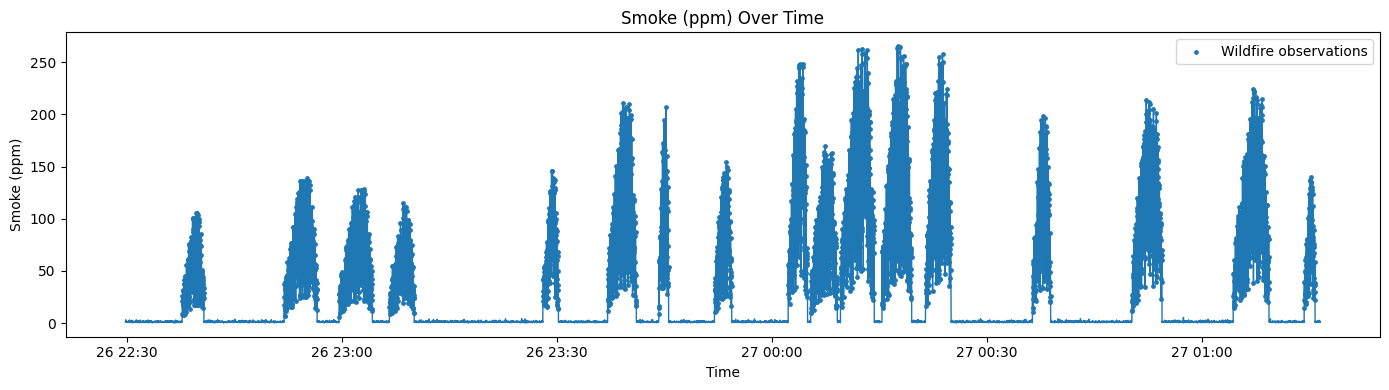

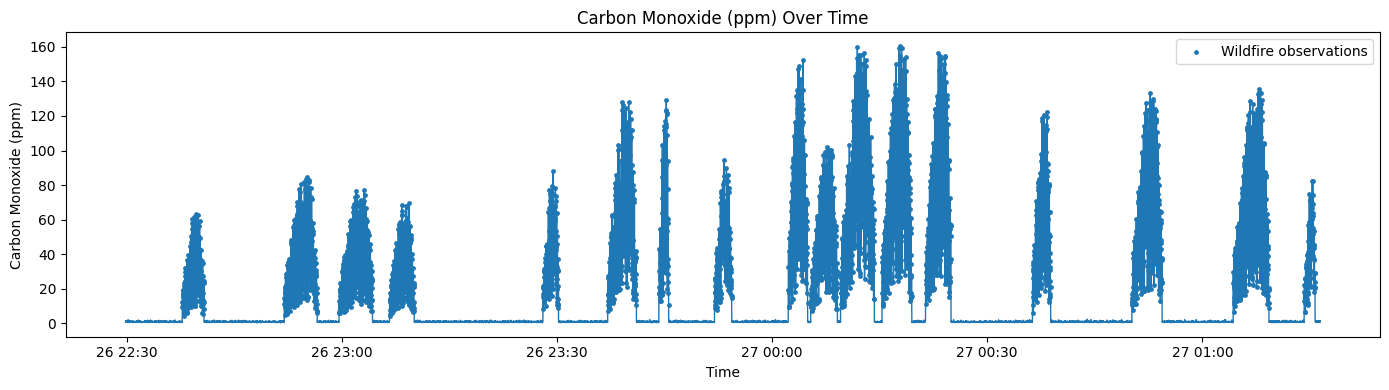

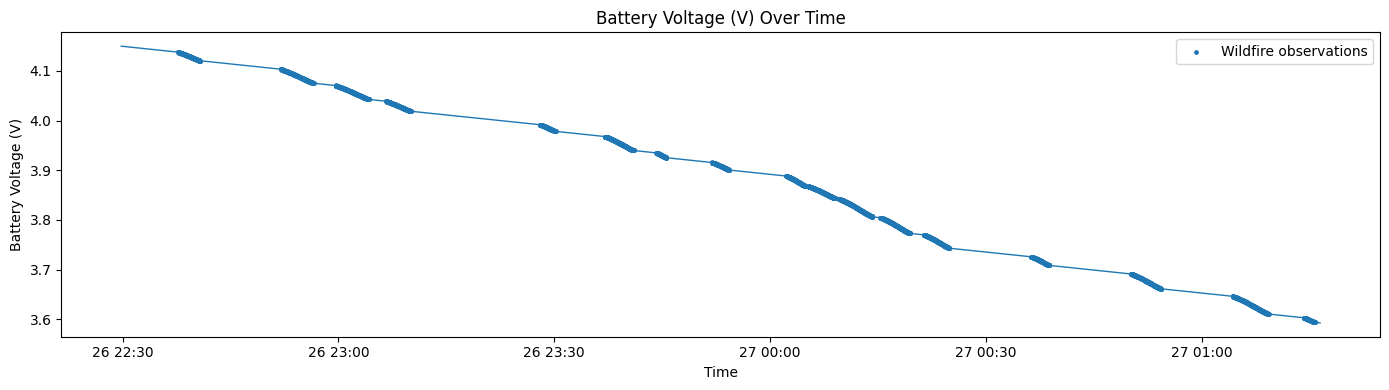

In [33]:
plot_variables = [
    ("temperature_c", "Temperature (C)"),
    ("humidity_percent", "Humidity (%)"),
    ("smoke_ppm", "Smoke (ppm)"),
    ("co_ppm", "Carbon Monoxide (ppm)"),
    ("battery_voltage", "Battery Voltage (V)")
]

for column, label in plot_variables:
    plt.figure(figsize=(14, 4))

    plt.plot(
        df["timestamp"],
        df[column],
        linewidth=1
    )

    fire_mask = df["wildfire"] == 1

    plt.scatter(
        df.loc[fire_mask, "timestamp"],
        df.loc[fire_mask, column],
        s=6,
        label="Wildfire observations"
    )

    plt.xlabel("Time")
    plt.ylabel(label)
    plt.title(f"{label} Over Time")
    plt.legend()
    plt.tight_layout()

    output_path = FIGURES_DIR / f"{column}_stream.png"

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

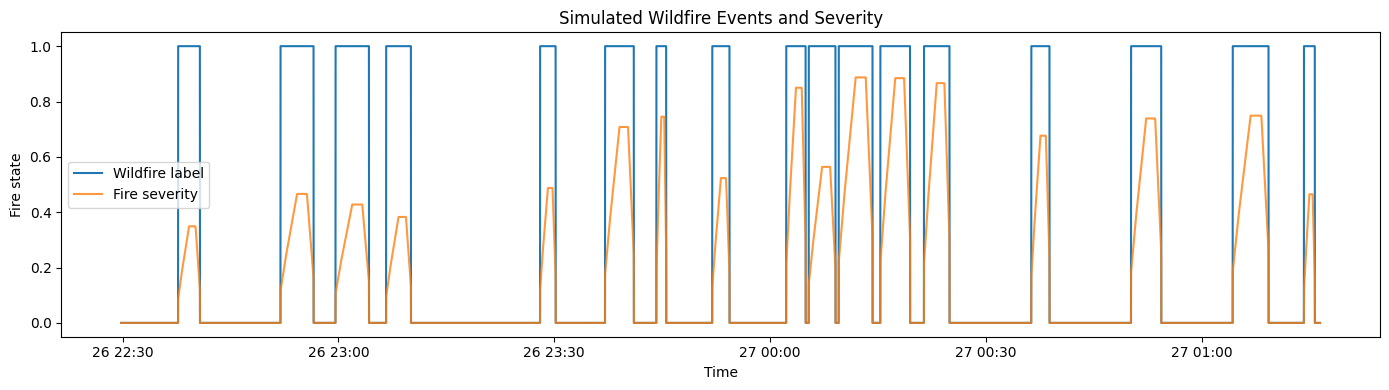

In [34]:
plt.figure(figsize=(14, 4))

plt.plot(
    df["timestamp"],
    df["wildfire"],
    label="Wildfire label"
)

plt.plot(
    df["timestamp"],
    df["fire_severity"],
    label="Fire severity",
    alpha=0.8
)

plt.xlabel("Time")
plt.ylabel("Fire state")
plt.title("Simulated Wildfire Events and Severity")
plt.legend()
plt.tight_layout()

wildfire_figure_path = (
    FIGURES_DIR / "wildfire_events_and_severity.png"
)

plt.savefig(
    wildfire_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
required_columns = [
    "timestamp",
    "sample_index",
    "temperature_c",
    "humidity_percent",
    "smoke_ppm",
    "co_ppm",
    "wind_speed_kmh",
    "solar_power_w",
    "battery_voltage",
    "wildfire",
    "fire_event_id",
    "fire_severity",
    "fire_phase"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

assert not missing_columns, (
    f"Missing required columns: {missing_columns}"
)

assert len(df) == config.total_samples
assert df["wildfire"].isin([0, 1]).all()
assert df["humidity_percent"].between(0, 100).all()
assert df["battery_voltage"].between(2.8, 4.2).all()

print("=" * 60)
print("ENVIRONMENTAL SIMULATOR COMPLETED SUCCESSFULLY")
print("=" * 60)
print("Total samples:", len(df))
print("Wildfire observations:", int(df["wildfire"].sum()))
print(
    "Wildfire events:",
    df.loc[df["wildfire"] == 1, "fire_event_id"].nunique()
)
print("Dataset:", environment_path)
print("Event summary:", wildfire_events_path)

ENVIRONMENTAL SIMULATOR COMPLETED SUCCESSFULLY
Total samples: 10000
Wildfire observations: 3462
Wildfire events: 17
Dataset: /content/wildfire-tinyml-self-sufficiency/data/simulated/baseline/week1_environment_stream.csv
Event summary: /content/wildfire-tinyml-self-sufficiency/data/simulated/baseline/week1_wildfire_events.csv
